In [82]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
from sklearn.preprocessing import normalize
from statsmodels.stats.proportion import proportions_ztest
import platform

In [83]:
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
import time
import random
from datetime import date

In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException

In [3]:
from sudachipy import tokenizer
from sudachipy import dictionary

In [128]:
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

In [84]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

In [86]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
import shap
from sklearn.model_selection import StratifiedKFold, cross_validate

In [87]:
#готовим модель машинного перевода с японского на русский
with open('warodai.txt', "r", encoding="utf-16") as f:
    content = f.read() #большой японо-русский словарь

In [88]:
entries = content.split('\n\n')[1:]

In [89]:
print (f'Всего в большом японо-русском словаре {len(entries)} слов')

Всего в большом японо-русском словаре 97226 слов


In [90]:
kanji_pattern = re.compile(r'【(.+?)】') #слова, которые пишутся иероглифами
kana_pattern = re.compile(r'^(\w+)') #слова, которые пишутся азбукой (каной)

In [91]:
words = []
for entry in entries:
    kanji = kanji_pattern.search(entry)
    kana = kana_pattern.search(entry)
    if kanji:
        result = kanji.group(1).split('･')[0]
    elif kana:
        result = kana.group(1)
    words.append (result)

In [92]:
translations = []
for entry in entries:
    clean = re.sub(r'<.{1,17}>', '', entry) #в словарной статье убираем пояснения в скобках
    clean = re.sub(r'\(.+?\)', '', clean) 
    clean = re.sub(r'\[.+\]', '', clean)
    clean = re.sub('\u0301', '', clean) #убираем знак ударения
    clean1 = re.split(r'[,;]', clean)[0] #берем первое значение из словарной статьи
    translation = re.search (r'[А-Яа-яЁё\s-]{3,}', clean1) #оставляем только слова, записанные кириллицей, и пробелы
    if translation:
        result = translation.group().strip()
    else:
        result = None
    translations.append(result)

In [93]:
print(translations[:20])

[None, None, None, None, 'взаимно', None, 'антракт', 'индиго', 'горе', 'любовь', 'невыносимо горестно', 'стелющийся', 'густой', 'идти под одним зонтиком', 'спорить  друг с другом', 'заботливое воспитание', 'детский сад', 'противоречить', 'совмещаться', 'тёмно-синий цвет']


In [94]:
vocab = pd.DataFrame (words, columns = ['word'])
vocab['translation'] = translations
vocab = vocab.dropna().reset_index(drop=True)

In [95]:
vocab.head(10)

,word,translation
0,相…,взаимно
1,間,антракт
2,藍,индиго
3,哀,горе
4,愛,любовь
5,哀々,невыносимо горестно
6,靄々,стелющийся
7,藹々,густой
8,相々傘,идти под одним зонтиком
9,相争う,спорить друг с другом


In [96]:
print (f'Всего в нашем словаре осталось {len(vocab)} слов')

Всего в нашем словаре осталось 88373 слов


In [97]:
#загружаем векторные модели для русского и японского языков (fasttext от Meta)
ja_vectors = KeyedVectors.load_word2vec_format('cc.ja.300.vec.gz', binary=False)
ru_vectors = KeyedVectors.load_word2vec_format('cc.ru.300.vec.gz', binary=False)

In [98]:
X_list = []
Y_list = []

for idx, row in vocab.iterrows():
    jp_word = row['word']
    ru_word = row['translation']
    if jp_word in ja_vectors and ru_word in ru_vectors: #проверяем, есть ли оба слова (на русском и на японском) в наших векторных моделях
        X_list.append(ja_vectors[jp_word])
        Y_list.append(ru_vectors[ru_word])

In [99]:
print (f'Всего нашлось {len (Y_list)} векторных представлений японских слов и их переводов на русский язык')

Всего нашлось 23960 векторных представлений японских слов и их переводов на русский язык


In [100]:
X = np.array(X_list)
Y = np.array(Y_list)

In [101]:
X_normalized = normalize(X, norm='l2', axis=1)
Y_normalized = normalize(Y, norm='l2', axis=1)

M = np.dot(X_normalized.T, Y_normalized) #вычисляем матрицу взаимной корреляции
U, S, Vt = np.linalg.svd(M) #применяем сингулярное разложение
W = np.dot(U, Vt) #рассчитываем итоговую матрицу трансформации

In [102]:
def test_vector_translation(model_W, ja_model, ru_model, target_word, top_k=5):
    '''функция для проверки качества перевода'''
    if target_word not in ja_model: #проверяем, есть ли векторное представление заданного слова в японской модели
        print(f"Ошибка: Японское слово '{target_word}' отсутствует в базовой модели fastText")
        return
    ja_vector = ja_model[target_word]
    predicted_ru_vector = np.dot(ja_vector, model_W) #переносим японский вектор в русское пространство при помощи матрицы W
    neighbors = ru_model.most_similar(positive=[predicted_ru_vector], topn=top_k) #ищем ближайших соседей в русском пространстве
    print(f'Японское слово: {target_word}')
    print(f'Топ-{top_k} вариантов перевода на русский:')
    for word, score in neighbors:
        print(f'    {word} (сходство: {score:.4f})')

In [103]:
test_vector_translation(W, ja_vectors, ru_vectors, target_word='プーチン', top_k=5) #тестируем перевод имен собственных

Японское слово: プーチン
Топ-5 вариантов перевода на русский:
    Путин (сходство: 0.6214)
    Путина (сходство: 0.5582)
    Жириновский (сходство: 0.5580)
    Обама (сходство: 0.5572)
    Медведев (сходство: 0.5340)


In [104]:
def translate_words(model_W, ja_model, ru_model, word_list, top_n_translations=1):
    '''функция перевода списка слов'''
    translated = []
    for jp_word in word_list:
        if jp_word in ja_model:
            ja_vector = ja_model[jp_word]
        else:
            translated.append(f"[{jp_word}?]")
            continue
        predicted_ru_vector = np.dot(ja_vector, model_W)
        neighbors = ru_model.most_similar(positive=[predicted_ru_vector], topn=top_n_translations)
        best_ru_word = neighbors[0][0] #забираем само слово, без коэффициента сходства
        translated.append(best_ru_word)        
    return translated

In [105]:
translate_words (W, ja_vectors, ru_vectors, ['価格', '上昇', '中国', '増', '元', '原油', 'ポイント', '輸出', '生産', '製造業'])

['цена',
 'снижение',
 'Китай',
 'увеличение',
 'бывший',
 'нефть',
 'бонус',
 'экспорт',
 'производство',
 '[製造業?]']

In [ ]:
url = 'https://news.yahoo.co.jp/categories/world' #парсим сайт новостного агрегатора

In [ ]:
driver = webdriver.Chrome()
driver.get(url)
selector = '#contentsWrap > nav > ul > li:nth-child(3) > button'
ss = WebDriverWait(driver, 10).until(EC.element_to_be_clickable((By.CSS_SELECTOR, selector))) 
ss.click() #переключаем на раздел, посвященный Китаю
time.sleep(2)
while True:
    try:
        selector2 = '#newsFeed > div > button'
        ss2 = WebDriverWait(driver, 10).until(EC.element_to_be_clickable((By.CSS_SELECTOR, selector2)))
        ss2.click() #прокручиваем динамическую страницу
        time.sleep (3)
    except TimeoutException:
        break
updated_html = driver.page_source
soup = BeautifulSoup(updated_html, 'html.parser')
driver.quit()

In [ ]:
news = soup.find('div', {'id': 'newsFeed'})
links = news.find_all('a') #ищем все ссылки на новости
urls = []
for link in links:
    if link.get('href'):
        if 'news.yahoo.co.jp/articles/' in link['href']:
            urls.append(link['href'])

In [340]:
print (f'Всего на одной динамической странице можно обнаружить {len(links)} ссылок. Из них - {len(urls)} ссылок на новостные статьи')

Всего на одной динамической странице можно обнаружить 2000 ссылок. Из них - 954 ссылок на новостные статьи


In [ ]:
def get_text (url):
    '''функция загрузки новостей по ссылке'''
    page = requests.get(url)
    soup = BeautifulSoup(page.text, features="html.parser")
    title = soup.find('h1', {'class': 'sc-uzx6gd-1 gGHJFY'}).get_text()
    date = soup.find ('time').get_text()
    comments = soup.find ('span', {'class': 'sc-1n9vtw0-3 fyikZi'})
    if comments:
        comments_number = soup.find ('span', {'class': 'sc-1n9vtw0-3 fyikZi'}).get_text()
    else:
        comments_number = 0
    source = soup.find ('a', {'class': 'sc-1enscux-0 ipFzZV'}).get('href')
    text = soup.find ('p', {'class': 'sc-54nboa-0 zUIkh yjSlinkDirectlink highLightSearchTarget'}).get_text().strip()
    return title, date, source, comments_number, text, url

In [342]:
all_news = []
for i in tqdm(range(len(urls))):
    new = get_text (urls[i])
    all_news.append (new)
    time.sleep(random.uniform(1.5, 3.0))

  0%|          | 0/954 [00:00<?, ?it/s]

100%|██████████| 954/954 [1:02:35<00:00,  3.94s/it]


In [ ]:
df = pd.DataFrame(all_news, columns = ['title', 'date', 'source', 'comments', 'text', 'url'])
df.to_excel('yahoo_news.xlsx')

In [106]:
df2 = pd.read_excel('yahoo_news_21jul.xlsx', index_col=0) #загружаем датасет, который собирался в течение 2,5 месяцев

In [107]:
print (f'Всего в нашем датасете {len(df2)} новостных статей')

Всего в нашем датасете 2223 новостных статей


<Axes: ylabel='count'>

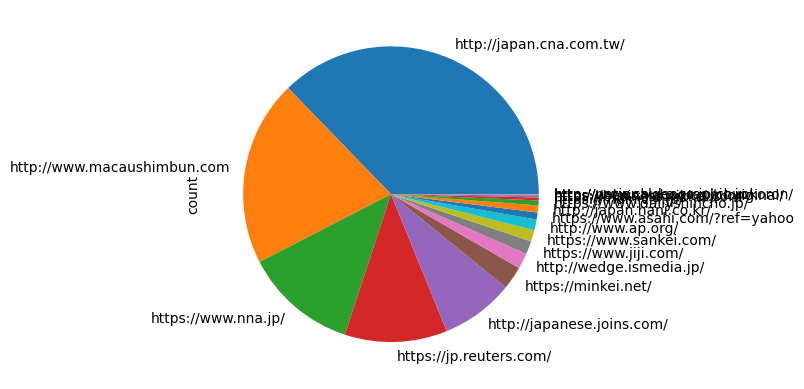

In [108]:
df2['source'].value_counts().plot(kind= 'pie')

In [109]:
df3 = df2[df2['source'] != 'http://www.macaushimbun.com'].reset_index (drop = True).copy() #убираем статьи про Макао, нас они не интересуют

In [110]:
print (f'После фильтра осталось {len(df3)} статей')

После фильтра осталось 1771 статей


In [111]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     1771 non-null   object
 1   date      1771 non-null   object
 2   source    1771 non-null   object
 3   comments  1771 non-null   int64 
 4   text      1771 non-null   object
 5   url       1771 non-null   object
dtypes: int64(1), object(5)
memory usage: 83.1+ KB


In [112]:
df3['comments'] = df3['comments'].astype(int)

In [113]:
def convert_date (date):
    '''переводим японскую запись даты в стандартный формат'''
    month = re.findall (r'\d+/', date)[0]
    day = re.findall (r'/\d+', date)[0]
    return pd.to_datetime(f"2026-{month}-{day}").date()

In [114]:
df3 ['datetime'] = df3['date'].apply (convert_date)

In [115]:
def clean_text (text):
    text_without_punct = re.sub(r'[\d+\s「」『』・、。\.,％◇■～\-－―／＊\*．─．：\:—＋●•＝…！‘’\u2060\u200b]', '', text)
    text_without_brackets = re.sub (r'（.+?）', '', text_without_punct)
    text_without_brackets2 = re.sub (r'【.+?】', '', text_without_brackets)
    text_without_brackets3 = re.sub (r'\[.+?\]', '', text_without_brackets2)
    text_without_brackets4 = re.sub (r'［.+?］', '', text_without_brackets3)
    text_without_brackets5 = re.sub (r'\(.+?\)', '', text_without_brackets4)
    text_without_english = re.sub(r'[A-Za-z]{9,}', '', text_without_brackets5)
    return (text_without_english)

In [116]:
df3['clean text'] = df3['text'].apply(clean_text)

In [117]:
stop_words_su = ['為る', '居る', '言う', '成る', 'つく', '巡る', '有る', 'よる', 'こと', '物', '日', '回', '今回', '月', 
                 '今月', '先月', '月日', '年', '去年','昨年', '今年', '年間', '午前', '午後', '述べる', '行う', '行く', 
                 '来る', '出来る', '見る', '対する', 'とも', '上', '際', '中', '他', '無い', '為', '凡そ', '%', '側', 
                 '人', '前', '後', '今後', '以降', '一方', '兆', '億', '万', '機', '間', 'うち', 'こう', '更に', '関する', 
                 'どう', 'よう', '示す', '万人', '念頭', '下旬', '中心', '発表', '保障', '分野', '面', '時間', '時', 
                 'おる', '同', '語る', '通じる', 'おく', '明らか', '前年', '数', '現在', '取る', '向ける', '比', '受ける', 
                 '話す', '以上', '1', '2', '3', '市', '県', '呉れる', '手掛ける', '箇月', '当局', 'ロイター']

In [118]:
print (f'В нашем списке {len(stop_words_su)} стоп-слов')

В нашем списке 94 стоп-слов


In [119]:
def tokenize_su (text):
    tokenizer_obj = dictionary.Dictionary().create()
    mode = tokenizer.Tokenizer.SplitMode.C
    tokenized = tokenizer_obj.tokenize(text, mode)
    allowed_pos = [
    '名詞',       # Существительное
    '動詞',       # Глагол
    '形容詞',     # Прилагательное
    '形状詞'      # Полупредикативные прилагательные
    ]
    meaningful_tokens = []
    for token in tokenized:
        if token.part_of_speech()[0] in allowed_pos:
            meaningful_tokens.append(token.normalized_form())
    stop_words = stop_words_su
    clean_tokens = []
    for token in meaningful_tokens:
        if token not in stop_words:
            clean_tokens.append(token)
    return clean_tokens

In [120]:
df3['tokens'] = df3['clean text'].apply (tokenize_su)

<Axes: ylabel='Frequency'>

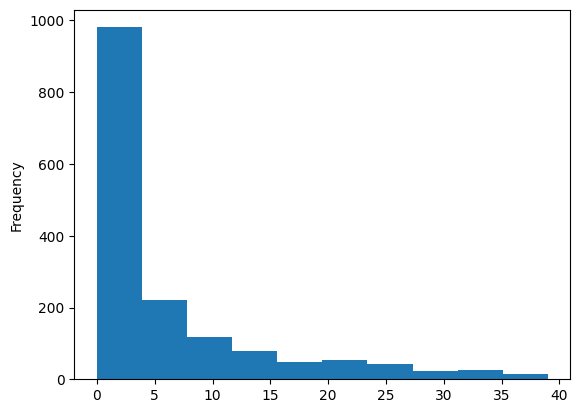

In [121]:
df3[df3['comments'] < 40]['comments'].plot (kind = 'hist')

In [122]:
df3['category'] = pd.cut(df3['comments'], 
                         bins=[-1, 15, np.inf], 
                         labels=[0, 1])

print(df3['category'].value_counts())

category
0    1400
1     371
Name: count, dtype: int64


In [123]:
df3['length'] = df3['tokens'].apply(len)

In [124]:
print (df3['length'].describe()) #описательная статистика по длине статей

count    1771.000000
mean      141.894975
std        88.275085
min         6.000000
25%        89.500000
50%       122.000000
75%       165.000000
max       883.000000
Name: length, dtype: float64


In [125]:
all_tokens = df3['tokens'].sum()

In [126]:
print (f'Всего в нашем датасете {len (all_tokens)} токенов, из них - {len (set(all_tokens))} уникальных токенов')

Всего в нашем датасете 251296 токенов, из них - 23244 уникальных токенов


In [129]:
#тематическое моделирование при помощи gensim
id2word = corpora.Dictionary(df3['tokens'])
id2word.filter_extremes(no_below=5, no_above=0.8)

In [130]:
corpus = []
for i in df3['tokens']:
    corpus.append(id2word.doc2bow(i))

In [131]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=id2word,
                                            num_topics=11,
                                            random_state=100,
                                            eta='auto',
                                            alpha='auto',
                                            passes=50
                                            )

In [132]:
topics = lda_model.print_topics(num_words=10)
for topic in topics:
  print(topic)

(0, '0.017*"香港" + 0.016*"AI" + 0.013*"企業" + 0.013*"半導体" + 0.013*"中国" + 0.010*"製造" + 0.010*"技術" + 0.009*"工場" + 0.009*"世界" + 0.007*"生産"')
(1, '0.013*"台湾" + 0.011*"台風" + 0.010*"中国" + 0.010*"北部" + 0.009*"南部" + 0.009*"キロ" + 0.008*"発生" + 0.007*"東部" + 0.007*"メートル" + 0.007*"号"')
(2, '0.018*"中国" + 0.015*"増" + 0.013*"価格" + 0.012*"元" + 0.010*"上昇" + 0.008*"市場" + 0.008*"輸出" + 0.008*"台" + 0.007*"ポイント" + 0.007*"供給"')
(3, '0.042*"台湾" + 0.012*"交流" + 0.010*"中国" + 0.009*"総統" + 0.009*"鄭" + 0.008*"協力" + 0.007*"国民" + 0.007*"発展" + 0.007*"民主主義" + 0.006*"国際"')
(4, '0.024*"台湾" + 0.011*"立法" + 0.010*"政府" + 0.008*"防衛" + 0.008*"法" + 0.008*"日本" + 0.007*"部" + 0.007*"調査" + 0.007*"国防" + 0.007*"委員会"')
(5, '0.041*"台湾" + 0.011*"台" + 0.010*"総統" + 0.009*"部" + 0.008*"産業" + 0.007*"外交" + 0.007*"韓国" + 0.007*"エスワティニ" + 0.007*"システム" + 0.007*"開発"')
(6, '0.050*"台湾" + 0.019*"日本" + 0.013*"文化" + 0.010*"台北" + 0.007*"開催" + 0.007*"代表" + 0.006*"紹介" + 0.006*"開く" + 0.006*"部" + 0.005*"イベント"')
(7, '0.021*"香港" + 0.010*"日本" + 0.008*"店舗" + 0.008

In [133]:
word_pattern = re.compile(r'"([^"]+)"')
for topic_id, topic_string in topics:
    topic_words = word_pattern.findall(topic_string)
    ru_words = translate_words(W, ja_vectors, ru_vectors, topic_words)
    print(f"Тема {topic_id}")
    print(topic_words)
    print(f"{ru_words}\n")

Тема 0
['香港', 'AI', '企業', '半導体', '中国', '製造', '技術', '工場', '世界', '生産']
['Гонконг', 'интеллект', 'корпорация', 'полупроводник', 'Китай', 'производство', 'технология', 'завод', 'мир', 'производство']

Тема 1
['台湾', '台風', '中国', '北部', '南部', 'キロ', '発生', '東部', 'メートル', '号']
['Китай', 'тайфун', 'Китай', 'северо-запад', 'округ', 'километров', 'возникновение', 'район', 'метров', '2013г']

Тема 2
['中国', '増', '価格', '元', '上昇', '市場', '輸出', '台', 'ポイント', '供給']
['Китай', 'увеличение', 'цена', 'бывший', 'снижение', 'рынок', 'экспорт', 'стационарная', 'бонус', 'снабжение']

Тема 3
['台湾', '交流', '中国', '総統', '鄭', '協力', '国民', '発展', '民主主義', '国際']
['Китай', 'общение', 'Китай', 'фюрер', 'Цзинхун', 'сотрудничество', 'народ', 'развитие', '[民主主義?]', 'международный']

Тема 4
['台湾', '立法', '政府', '防衛', '法', '日本', '部', '調査', '国防', '委員会']
['Китай', 'парламент', 'правительство', 'оборона', 'принцип', 'Япония', 'часть', 'исследование', 'обороноспособность', '[委員会?]']

Тема 5
['台湾', '台', '総統', '部', '産業', '外交', '韓国', 'エスワティニ'

In [134]:
coherence_model_lda = CoherenceModel(model=lda_model, texts=df3['tokens'], dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score для модели LDA {coherence_lda}')

Coherence Score для модели LDA 0.5394589323757467


In [135]:
df3['tokens_blanc'] = df3['tokens'].apply (lambda x: " ".join(x))

In [136]:
#тематическое моделирование при помощи BERTopic
vectorizer_model = CountVectorizer(token_pattern=r'\S+')

umap_model = UMAP(
    n_neighbors=19, #меньше - локальные связи, больше - глобальные связи (более широкие темы)
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42, #для воспроизводимости результата
)

hdbscan_model = HDBSCAN(
    min_cluster_size=40,   #минимальный размер кластера (надо установить вручную, тк у нас маленький датасет)
    min_samples=2,         #чем меньше, тем меньше текстов уйдет в категорию -1 (шум)
    metric='euclidean', 
    cluster_selection_method='eom'
)

topic_model = BERTopic(
    umap_model=umap_model,
    embedding_model="paraphrase-multilingual-MiniLM-L12-v2",
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    min_topic_size=40,  #минимальное кол-во текстов в теме
    low_memory=True,
    verbose=True
)

In [137]:
topics_bert, probs = topic_model.fit_transform(df3['tokens_blanc'])

2026-07-28 17:51:21,551 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/56 [00:00<?, ?it/s]

2026-07-28 17:52:33,829 - BERTopic - Embedding - Completed ✓
2026-07-28 17:52:33,831 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-28 17:52:42,224 - BERTopic - Dimensionality - Completed ✓
2026-07-28 17:52:42,225 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-28 17:52:42,295 - BERTopic - Cluster - Completed ✓
2026-07-28 17:52:42,300 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-28 17:52:42,578 - BERTopic - Representation - Completed ✓


In [138]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,217,-1_台湾_中国_台_フィリピン,"[台湾, 中国, 台, フィリピン, 日本, 販売, 元, 地震, 震度, 南]",[世界 最大級 自動車 展示会 北京 国際 汽車 展覧会 北京市 開幕 日系 メーカー 電動...
1,0,475,0_香港_台湾_文化_日本,"[香港, 台湾, 文化, 日本, 中国, 台北, 店舗, 交流, 展示, 作品]",[香港 旺角東駅 直結 ショッピングモール mokomall 日本 人気 キャラクター かわ...
2,1,320,1_中国_台湾_米国_会談,"[中国, 台湾, 米国, 会談, 関係, 主席, イラン, 総統, 訪問, 外交]",[会談 互い 認める 否定 会談 台湾 政治 厳 震生 教授 北京 米中 首脳 会談 同床 ...
3,2,142,2_中国_台湾_演習_訓練,"[中国, 台湾, 演習, 訓練, 海域, 発射, 国防, 無人機, 実施, 軍]",[中国 太平洋 潜水艦 発射 弾道 ミサイル 試験 発射 中国 国営 新華 社 通信 中国 ...
4,3,127,3_ai_半導体_製造_企業,"[ai, 半導体, 製造, 企業, 工場, tsmc, 台湾, ロボット, 生産, 製品]",[中国 自国 人工知能 企業 エヌビディア 高性能 グラフィックス 処理 装置 購入 一部 ...
5,4,112,4_台湾_車両_乗客_台北,"[台湾, 車両, 乗客, 台北, 韓国, 航空, 空港, 香港, 日本, 運転]",[台湾 高速 鉄道 混雑 緩和 台北駅 ホーム 東側 出口 繋がる 新た 通路 供用 開始 ...
6,5,93,5_上昇_ポイント_増_前月,"[上昇, ポイント, 増, 前月, 製造業, 中国, 価格, 金融, 香港, 統計]",[中国 国家 統計 局 中国 物流 購買 連合会 製造業 景況感 製造業 購買 担当者 指数...
7,6,70,6_価格_原油_中国_輸出,"[価格, 原油, 中国, 輸出, 中東, 元, 供給, 石油, 上昇, 増]",[中国 中東 情勢 不安 国際 原油 価格 変動 大きい 状況 入る 国内 原油 価格 引き...
8,7,59,7_大会_野球_試合_台湾,"[大会, 野球, 試合, 台湾, プロ, 投手, 選手, 林, 勝利, 本塁打]",[台湾 プロ 野球 統一 ライオンズ 日本 拠 地 アジア 太平洋 国際 野球 訓練 センタ...
9,8,55,8_台風_気象_影響_北部,"[台風, 気象, 影響, 北部, 風速, キロ, ミリ, 号, 豪雨, 被害]",[中央 気象 台湾 接近 強烈 台風 台風 号 台湾 影響 顕著 日夜 かける 台湾 北東 ...


In [139]:
#распределяем тексты из группы -1 по другим темам
new_topics = topic_model.reduce_outliers(
    documents = df3['tokens_blanc'],
    topics = topics_bert, 
    strategy="c-tf-idf"
)

In [140]:
topic_model.update_topics(df3['tokens_blanc'], topics=new_topics)

2026-07-28 17:53:39,801 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [141]:
for topic, words in topic_model.get_topics().items():
    topic_words = []
    for word, score in words:
        topic_words.append(word)
    ru_words = translate_words(W, ja_vectors, ru_vectors, topic_words)
    print(f"Тема {topic}")
    print(topic_words)
    print(f"{ru_words}\n")

Тема 0
['台湾', '香港', '日本', '文化', '中国', '台北', '店舗', '交流', '展示', 'イベント']
['Китай', 'Гонконг', 'Япония', 'культура', 'Китай', 'Гуанчжоу', 'магазина', 'общение', 'выставка', 'мероприятие']

Тема 1
['中国', '台湾', '米国', '関係', '会談', '主席', 'イラン', '総統', '訪問', '外交']
['Китай', 'Китай', 'США', 'взаимоотношение', 'переговоры', 'секретарь', 'Иран', 'фюрер', 'посещение', 'дипломатия']

Тема 2
['中国', '台湾', '演習', '国防', '海域', '訓練', '実施', '海洋', '無人機', '発射']
['Китай', 'Китай', 'тренировка', 'обороноспособность', 'акватория', 'тренировка', 'проведение', 'океанологический', '[無人機?]', 'выстреливание']

Тема 3
['ai', '半導体', '製造', '企業', 'tsmc', '製品', '台湾', '中国', '世界', '工場']
['xe', 'полупроводник', 'производство', 'корпорация', '[tsmc?]', 'продукция', 'Китай', 'Китай', 'мир', 'завод']

Тема 4
['台湾', '車両', '台北', '乗客', '空港', '韓国', '航空', '香港', '日本', '利用']
['Китай', 'автомобиль', 'Гуанчжоу', 'пассажиров', 'аэропорт', 'Корея', 'авиация', 'Гонконг', 'Япония', 'использование']

Тема 5
['上昇', 'ポイント', '前月', '中国', '指数', '価格

In [142]:
bert_topics = []
for topic, words in topic_model.get_topics().items():
    words_list = []
    for word, score in words:
        words_list.append (word)
    bert_topics.append (words_list)
coherence_model = CoherenceModel(
    topics=bert_topics, 
    texts=df3['tokens'], 
    dictionary=id2word, 
    coherence='c_v'
)

print(f"BERTopic Coherence Score после reduce_outliers: {coherence_model.get_coherence():.4f}")

BERTopic Coherence Score после reduce_outliers: 0.6106


In [143]:
fig_hierarchy = topic_model.visualize_hierarchy()
fig_hierarchy.show()

In [144]:
fig_docs = topic_model.visualize_documents(df3['tokens_blanc'].tolist())
fig_docs.show()

In [145]:
df3['bertopic_id'] = new_topics

In [146]:
df3.groupby ('bertopic_id')['comments'].agg(['mean', 'median'])

,mean,median
bertopic_id,,
0,10.288760,1.0
1,23.771429,8.0
2,42.347561,6.0
3,8.441379,1.0
4,11.487805,2.0
5,4.820513,1.0
6,15.236559,3.0
7,5.459016,2.0
8,13.285714,2.0


In [147]:
aux_table = pd.crosstab (df3['bertopic_id'], df3['category'])
aux_table

category,0,1
bertopic_id,,
0,450,66
1,233,117
2,114,50
3,132,13
4,112,11
5,104,13
6,69,24
7,58,3
8,58,12


In [148]:
n = len(aux_table)
alpha_bonferroni = 0.05 / n #новая граница значимости, с поправкой Бонферрони (для множественных тестов)
total_popular = aux_table[1].sum()
total_news = aux_table.sum().sum()
results = []
for topic_id in aux_table.index:
    topic_popular = aux_table.loc[topic_id, 1]
    topic_total = aux_table.loc[topic_id].sum()
    share = topic_popular / topic_total
    count = np.array([topic_popular, total_popular])
    nobs = np.array([topic_total, total_news])
    _, p_z = proportions_ztest(count, nobs, alternative='larger') #Z-тест, проверяем гипотезу, что доля популярных в теме выше средней по корпусу
    is_significant = p_z < alpha_bonferroni
    results.append({'Topic (BERT)': topic_id,
                    'Total': topic_total,
                    'Popular': topic_popular,
                    'Share': round(share * 100, 1),
                    'p-value (Z-test)': round(p_z, 6),
                    'Significance': '***' if p_z < 0.001 else '**' if p_z < 0.005 else '*' if is_significant else 'ns'})
results_df = pd.DataFrame(results)

In [149]:
print(results_df.to_string(index=False))

 Topic (BERT)  Total  Popular  Share  p-value (Z-test) Significance
            0    516       66   12.8          0.999983           ns
            1    350      117   33.4          0.000000          ***
            2    164       50   30.5          0.002309           **
            3    145       13    9.0          0.999735           ns
            4    123       11    8.9          0.999333           ns
            5    117       13   11.1          0.994772           ns
            6     93       24   25.8          0.131913           ns
            7     61        3    4.9          0.998871           ns
            8     70       12   17.1          0.779170           ns
            9     72       27   37.5          0.000410          ***
           10     60       35   58.3          0.000000          ***


In [150]:
df4 = df3 [['category', 'text', 'tokens', 'bertopic_id']]

In [151]:
train_df, test_df = train_test_split(
    df4,
    test_size=0.2,
    random_state=42,
    stratify=df4['category'],
    shuffle = True
)

In [33]:
all_tokens_train = train_df['tokens'].sum()

In [346]:
print (f'В нашей тренировочной выборке {len (all_tokens_train)} токенов, из них {len(set(all_tokens_train))} уникальных токенов')

В нашей тренировочной выборке 201969 токенов, из них 20760 уникальных токенов


In [34]:
def news_tokenizer (text):
    return (text)

In [35]:
tf_vectorizer = TfidfVectorizer(
    tokenizer=news_tokenizer,  #загружаем в векторайзер уже токенизированный ранее текст
    preprocessor=news_tokenizer,
    token_pattern=None,
    max_features=3000, min_df=3, max_df=0.7
    )

In [36]:
tf_vectorizer.fit(train_df['tokens'])

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,<function new...0019D39071120>
,tokenizer,<function new...0019D39071120>
,analyzer,'word'
,stop_words,None
,token_pattern,None
,ngram_range,"(1, ...)"


In [37]:
X_train = tf_vectorizer.transform (train_df['tokens'])
X_test = tf_vectorizer.transform (test_df['tokens'])

In [38]:
y_train = train_df['category']
y_test = test_df['category']

In [39]:
results_report = []

In [40]:
def scores (model, y_test, y_pred):
  report_dict = classification_report(y_test, y_pred, output_dict=True)
  accuracy = report_dict['accuracy']
  f1_macro = report_dict['macro avg']['f1-score'] #больше всего нас интересует эта метрика, тк есть дисбаланс классов
  precision = report_dict ['macro avg']['precision']
  recall = report_dict ['macro avg']['recall']
  results_report.append ([model, accuracy, f1_macro, precision, recall])
  return results_report

In [41]:
model_lr = LogisticRegression(class_weight='balanced', random_state=42)

In [42]:
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [43]:
pred_lr = model_lr.predict(X_test)

In [44]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88       281
           1       0.53      0.65      0.59        74

    accuracy                           0.81       355
   macro avg       0.72      0.75      0.73       355
weighted avg       0.83      0.81      0.81       355



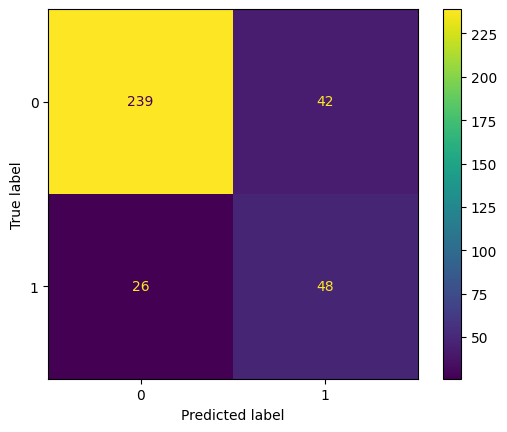

In [270]:
cm = confusion_matrix(y_test, pred_lr)
cm_display = ConfusionMatrixDisplay(cm).plot()

In [271]:
features_df = pd.DataFrame()
features_df['token'] = tf_vectorizer.get_feature_names_out()
features_df['coef'] = model_lr.coef_[0]

In [272]:
rus = translate_words(W, ja_vectors, ru_vectors, features_df['token'])

In [273]:
features_df['rus'] = rus
coefficients = features_df.sort_values(by='coef', ascending=False).reset_index(drop=True)

In [ ]:
coefficients.head(14) #признаки, указывающие на класс "популярные"

,token,coef,rus
0,中国,5.398073,Китай
1,日本,2.342681,Япония
2,中国人,1.600559,китаец
3,メディア,1.409912,массмедиа
4,販売,1.294274,продажа
5,輸出,1.174174,экспорт
6,自動車,1.172255,автомобиль
7,発言,1.146128,высказывание
8,男性,1.142283,мужчина
9,ガソリン,1.141927,бензин


In [348]:
coefficients.tail(14)

,token,coef,rus
2986,陳,-0.696472,Чуань
2987,イベント,-0.716280,мероприятие
2988,中朝,-0.731333,[中朝?]
2989,展示,-0.759920,выставка
2990,観光,-0.768954,туризм
2991,習氏,-0.819443,Пекин
2992,文化,-0.894832,культура
2993,製造,-0.902798,производство
2994,高雄,-0.907906,Цзинань
2995,増,-1.157002,увеличение


In [45]:
scores ('LogisticRegression', y_test, pred_lr)

[['LogisticRegression',
  0.8084507042253521,
  0.7304118645582061,
  0.7176100628930817,
  0.7495912282389151]]

In [46]:
encoder = OneHotEncoder()
encoder.fit(train_df['bertopic_id'].values.reshape(-1, 1)) #добавим номер темы в список признаков

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [47]:
X_train_topic = encoder.transform(train_df['bertopic_id'].values.reshape(-1, 1))
X_test_topic = encoder. transform (test_df['bertopic_id'].values.reshape(-1, 1))

In [48]:
X_train_final = hstack([X_train, X_train_topic])
X_test_final = hstack([X_test, X_test_topic])

In [49]:
model_lr.fit(X_train_final, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [50]:
pred_lr_topic = model_lr.predict(X_test_final)

In [51]:
print(classification_report(y_test, pred_lr_topic))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86       281
           1       0.48      0.61      0.54        74

    accuracy                           0.78       355
   macro avg       0.69      0.72      0.70       355
weighted avg       0.80      0.78      0.79       355



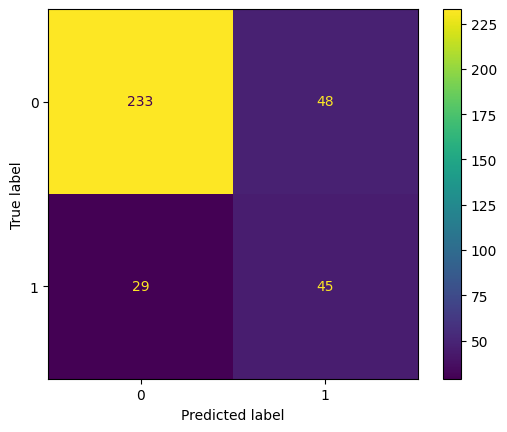

In [282]:
cm2 = confusion_matrix(y_test, pred_lr_topic)
cm_display2 = ConfusionMatrixDisplay(cm2).plot()

In [52]:
scores ('LogisticRegression + BERTopic', y_test, pred_lr_topic)

[['LogisticRegression',
  0.8084507042253521,
  0.7304118645582061,
  0.7176100628930817,
  0.7495912282389151],
 ['LogisticRegression + BERTopic',
  0.7830985915492957,
  0.6985586837374974,
  0.686591972420586,
  0.7186448013850149]]

In [53]:
model_svc = LinearSVC (class_weight='balanced', random_state=42) #линейная классификация методом опорных векторов

In [54]:
model_svc.fit (X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [55]:
pred_svc = model_svc.predict (X_test)

In [56]:
print (classification_report (y_test, pred_svc))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       281
           1       0.61      0.55      0.58        74

    accuracy                           0.83       355
   macro avg       0.75      0.73      0.74       355
weighted avg       0.83      0.83      0.83       355



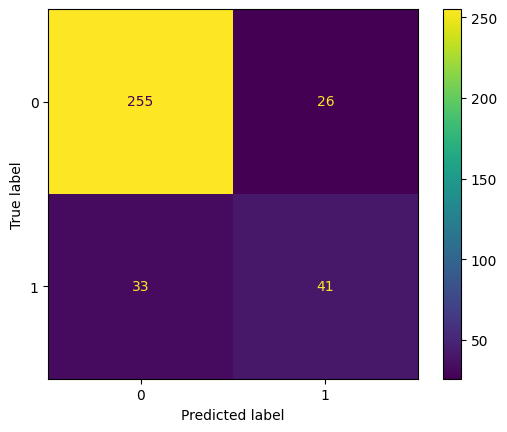

In [288]:
cm3 = confusion_matrix(y_test, pred_svc)
cm_display3 = ConfusionMatrixDisplay(cm3).plot()

In [289]:
features_df2 = pd.DataFrame()
features_df2['token'] = tf_vectorizer.get_feature_names_out()
features_df2['coef'] = model_svc.coef_[0]

In [290]:
features_df2['rus'] = rus
coefficients2 = features_df2.sort_values(by='coef', ascending=False).reset_index(drop=True)

In [291]:
coefficients2.head(15)

,token,coef,rus
0,中国,2.444477,Китай
1,日本,1.595621,Япония
2,メディア,1.510814,массмедиа
3,中国人,1.428640,китаец
4,販売,1.401587,продажа
5,ガソリン,1.321891,бензин
6,青年,1.251595,юноша
7,不合格,1.238152,доучиться
8,習近平,1.210993,[習近平?]
9,発言,1.192029,высказывание


In [349]:
coefficients2.tail(11)

,token,coef,rus
2989,訪日,-0.870490,визита
2990,増える,-0.903425,увеличиваться
2991,台北,-0.932315,Гуанчжоу
2992,王毅,-0.946419,[王毅?]
2993,研究,-0.951124,исследование
2994,実験,-0.984472,эксперимент
2995,香港,-1.005480,Гонконг
2996,件,-1.151536,Еще
2997,訪問,-1.189992,посещение
2998,習氏,-1.414498,Пекин


In [57]:
scores ('LinearSVC', y_test, pred_svc)

[['LogisticRegression',
  0.8084507042253521,
  0.7304118645582061,
  0.7176100628930817,
  0.7495912282389151],
 ['LogisticRegression + BERTopic',
  0.7830985915492957,
  0.6985586837374974,
  0.686591972420586,
  0.7186448013850149],
 ['LinearSVC',
  0.8338028169014085,
  0.738934799137469,
  0.7486784825870647,
  0.7307636818312975]]

In [58]:
model_nb = ComplementNB () #наивный Байес для дисбаланса классов

In [59]:
model_nb.fit (X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,norm,False


In [60]:
pred_nb = model_nb.predict (X_test)

In [61]:
print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       281
           1       0.51      0.65      0.57        74

    accuracy                           0.80       355
   macro avg       0.71      0.74      0.72       355
weighted avg       0.82      0.80      0.81       355



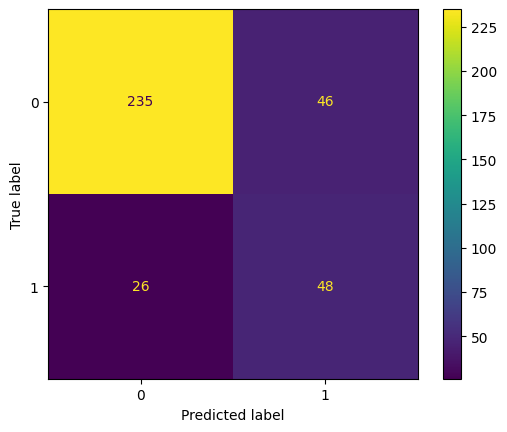

In [298]:
cm4 = confusion_matrix(y_test, pred_nb)
cm_display4 = ConfusionMatrixDisplay(cm4).plot()

In [62]:
scores ('ComplementNB', y_test, pred_nb)

[['LogisticRegression',
  0.8084507042253521,
  0.7304118645582061,
  0.7176100628930817,
  0.7495912282389151],
 ['LogisticRegression + BERTopic',
  0.7830985915492957,
  0.6985586837374974,
  0.686591972420586,
  0.7186448013850149],
 ['LinearSVC',
  0.8338028169014085,
  0.738934799137469,
  0.7486784825870647,
  0.7307636818312975],
 ['ComplementNB',
  0.7971830985915493,
  0.7192936215076436,
  0.7055107198173962,
  0.7424737905164951]]

In [63]:
model_rf = RandomForestClassifier (class_weight='balanced', random_state=42)

In [64]:
model_rf.fit (X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
pred_rf = model_rf.predict (X_test)

In [66]:
print (classification_report (y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.98      0.90       281
           1       0.76      0.30      0.43        74

    accuracy                           0.83       355
   macro avg       0.80      0.64      0.66       355
weighted avg       0.82      0.83      0.80       355



In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(model_rf, X_train, y_train, cv=skf, scoring='f1_macro', return_train_score=True)

print(f"Средний F1-score на тесте: {results['test_score'].mean():.2f}")
print(f"Средний F1-score на обучении: {results['train_score'].mean():.2f}") #модель явно переобучается

Средний F1-score на тесте: 0.64
Средний F1-score на обучении: 1.00


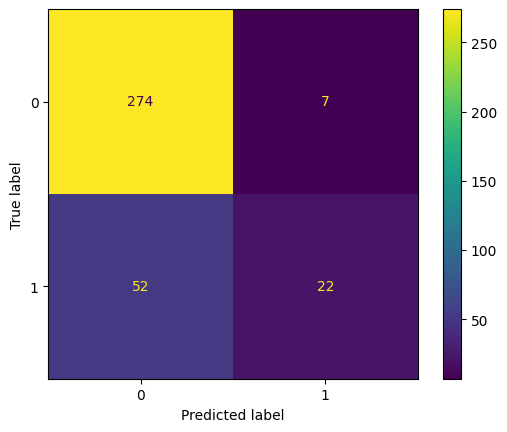

In [305]:
cm5 = confusion_matrix (y_test, pred_rf)
cm_display5 = ConfusionMatrixDisplay (cm5).plot()

In [67]:
scores ('RandomForest', y_test, pred_rf)

[['LogisticRegression',
  0.8084507042253521,
  0.7304118645582061,
  0.7176100628930817,
  0.7495912282389151],
 ['LogisticRegression + BERTopic',
  0.7830985915492957,
  0.6985586837374974,
  0.686591972420586,
  0.7186448013850149],
 ['LinearSVC',
  0.8338028169014085,
  0.738934799137469,
  0.7486784825870647,
  0.7307636818312975],
 ['ComplementNB',
  0.7971830985915493,
  0.7192936215076436,
  0.7055107198173962,
  0.7424737905164951],
 ['RandomForest',
  0.8338028169014085,
  0.6649925624990003,
  0.7995557436005923,
  0.6361931326344138]]

In [68]:
model_rf2 = BalancedRandomForestClassifier(n_estimators=100, random_state=42)

In [69]:
model_rf2.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [70]:
pred_rf2 = model_rf2.predict (X_test)

In [71]:
print (classification_report (y_test, pred_rf2))

              precision    recall  f1-score   support

           0       0.91      0.81      0.86       281
           1       0.49      0.68      0.57        74

    accuracy                           0.79       355
   macro avg       0.70      0.75      0.71       355
weighted avg       0.82      0.79      0.80       355



In [363]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(model_rf2, X_train, y_train, cv=skf, scoring='f1_macro', return_train_score=True)

print(f"Средний F1-score на тесте: {results['test_score'].mean():.2f}")
print(f"Средний F1-score на обучении: {results['train_score'].mean():.2f}")

Средний F1-score на тесте: 0.70
Средний F1-score на обучении: 0.94


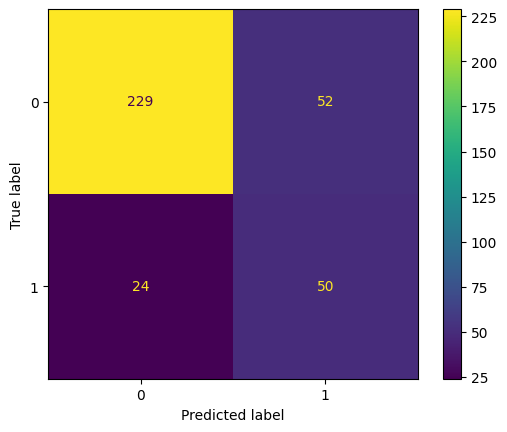

In [364]:
cm6 = confusion_matrix (y_test, pred_rf2)
cm_display6 = ConfusionMatrixDisplay (cm6).plot()

In [374]:
explainer = shap.TreeExplainer(model_rf2)

In [375]:
X_test_dense = X_test.toarray() #переводим разреженную матрицу в плотную

In [376]:
shap_values = explainer.shap_values(X_test_dense, check_additivity=False) #адаптируем эксплейнер к BalancedRandomForestClassifier

In [395]:
# Этот кусочек написан ИИ, для правильного отображения иероглифов на графике
# Автоматически выбираем шрифт в зависимости от операционной системы
if platform.system() == "Windows":
    plt.rcParams['font.family'] = 'MS Gothic'
elif platform.system() == "Darwin":  # macOS
    plt.rcParams['font.family'] = 'Hiragino Maru Gothic Pro'
else:
    plt.rcParams['font.family'] = 'sans-serif'

# Защита от неправильного отображения знака "минус" на осях SHAP при смене шрифта
plt.rcParams['axes.unicode_minus'] = False

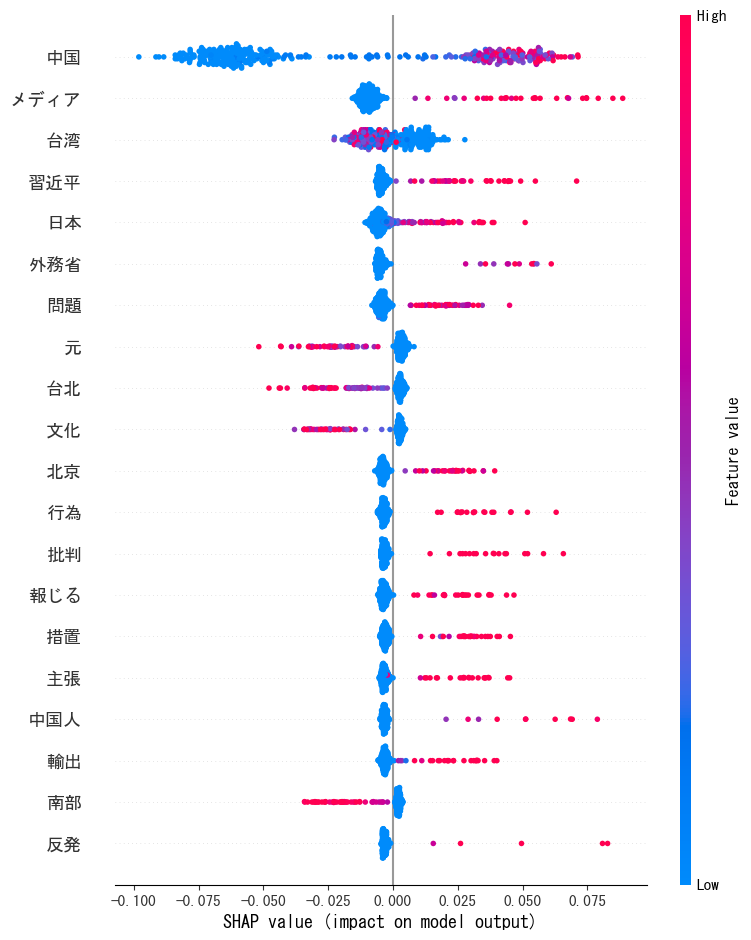

In [394]:
shap.summary_plot(shap_values[:, :, 1], X_test_dense, feature_names=tf_vectorizer.get_feature_names_out())

In [72]:
scores ('RandomForest_Balanced', y_test, pred_rf2)

[['LogisticRegression',
  0.8084507042253521,
  0.7304118645582061,
  0.7176100628930817,
  0.7495912282389151],
 ['LogisticRegression + BERTopic',
  0.7830985915492957,
  0.6985586837374974,
  0.686591972420586,
  0.7186448013850149],
 ['LinearSVC',
  0.8338028169014085,
  0.738934799137469,
  0.7486784825870647,
  0.7307636818312975],
 ['ComplementNB',
  0.7971830985915493,
  0.7192936215076436,
  0.7055107198173962,
  0.7424737905164951],
 ['RandomForest',
  0.8338028169014085,
  0.6649925624990003,
  0.7995557436005923,
  0.6361931326344138],
 ['RandomForest_Balanced',
  0.7859154929577464,
  0.7129298604017705,
  0.6976672091761605,
  0.7453111474463787]]

In [73]:
results_table = pd.DataFrame (results_report, columns=['model', 'accuracy', 'f1_macro', 'precision', 'recall'])
results_table.sort_values(by='f1_macro', ascending=False)

,model,accuracy,f1_macro,precision,recall
2,LinearSVC,0.833803,0.738935,0.748678,0.730764
0,LogisticRegression,0.808451,0.730412,0.717610,0.749591
3,ComplementNB,0.797183,0.719294,0.705511,0.742474
5,RandomForest_Balanced,0.785915,0.712930,0.697667,0.745311
1,LogisticRegression + BERTopic,0.783099,0.698559,0.686592,0.718645
4,RandomForest,0.833803,0.664993,0.799556,0.636193


In [74]:
base_models = [
    ('SVC', LinearSVC(class_weight='balanced')),
    ('LR', LogisticRegression(class_weight='balanced')),
    ('RF', BalancedRandomForestClassifier(n_estimators=100))
]
meta_model = LogisticRegression()

In [75]:
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
)

In [76]:
stacking_model.fit (X_train, y_train)

,estimators,"[('SVC', ...), ('LR', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


In [77]:
pred_stacking = stacking_model.predict(X_test)

In [78]:
print (classification_report(y_test, pred_stacking))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91       281
           1       0.71      0.43      0.54        74

    accuracy                           0.85       355
   macro avg       0.79      0.69      0.72       355
weighted avg       0.83      0.85      0.83       355



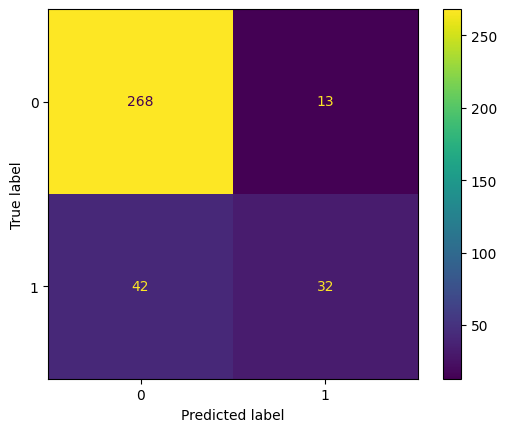

In [332]:
cm7 = confusion_matrix (y_test, pred_stacking)
cm_display7 = ConfusionMatrixDisplay (cm7).plot()

In [79]:
scores ('Stacking (SVC_LR_RF)', y_test, pred_stacking)

[['LogisticRegression',
  0.8084507042253521,
  0.7304118645582061,
  0.7176100628930817,
  0.7495912282389151],
 ['LogisticRegression + BERTopic',
  0.7830985915492957,
  0.6985586837374974,
  0.686591972420586,
  0.7186448013850149],
 ['LinearSVC',
  0.8338028169014085,
  0.738934799137469,
  0.7486784825870647,
  0.7307636818312975],
 ['ComplementNB',
  0.7971830985915493,
  0.7192936215076436,
  0.7055107198173962,
  0.7424737905164951],
 ['RandomForest',
  0.8338028169014085,
  0.6649925624990003,
  0.7995557436005923,
  0.6361931326344138],
 ['RandomForest_Balanced',
  0.7859154929577464,
  0.7129298604017705,
  0.6976672091761605,
  0.7453111474463787],
 ['Stacking (SVC_LR_RF)',
  0.8450704225352113,
  0.7223762601487296,
  0.7878136200716845,
  0.6930845436183515]]

In [80]:
results_table2 = pd.DataFrame (results_report, columns=['model', 'accuracy', 'f1_macro', 'precision', 'recall'])
results_table2.sort_values(by='f1_macro', ascending=False)

,model,accuracy,f1_macro,precision,recall
2,LinearSVC,0.833803,0.738935,0.748678,0.730764
0,LogisticRegression,0.808451,0.730412,0.717610,0.749591
6,Stacking (SVC_LR_RF),0.845070,0.722376,0.787814,0.693085
3,ComplementNB,0.797183,0.719294,0.705511,0.742474
5,RandomForest_Balanced,0.785915,0.712930,0.697667,0.745311
1,LogisticRegression + BERTopic,0.783099,0.698559,0.686592,0.718645
4,RandomForest,0.833803,0.664993,0.799556,0.636193


In [81]:
results_table2.to_excel('classic_models_results.xlsx')